In [2]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [3]:
iris = load_iris()
print(dir(iris))
df = pd.DataFrame(iris.data, columns = iris.feature_names)
df['target'] = iris.target
print(df.head())
df.info()

['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)  

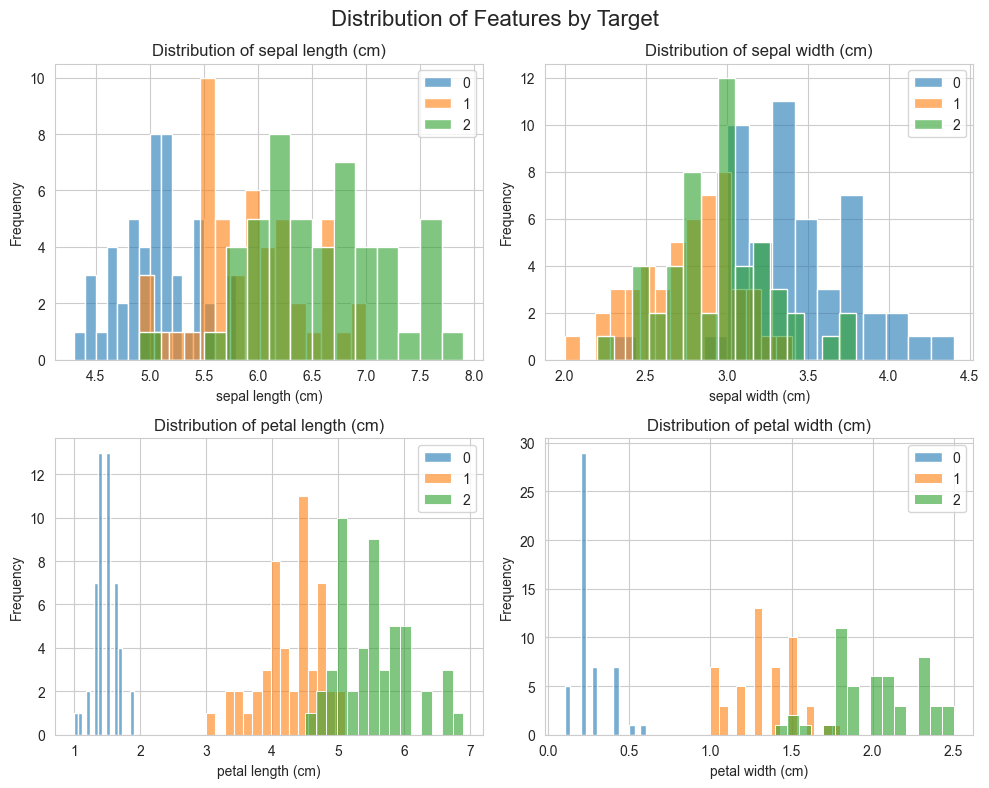

In [4]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 8))

# List of features (excluding the 'target' column)
features = df.columns[:-1]  # or df.iloc[:, :-1].columns

for i, feature in enumerate(features):
    plt.subplot(2, 2, i + 1)
    for target_class in df['target'].unique():
        subset = df[df['target'] == target_class]
        sns.histplot(subset[feature], bins=15, label=str(target_class), kde=False, alpha=0.6)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.legend()

plt.suptitle("Distribution of Features by Target", fontsize=16)
plt.tight_layout()
plt.show()

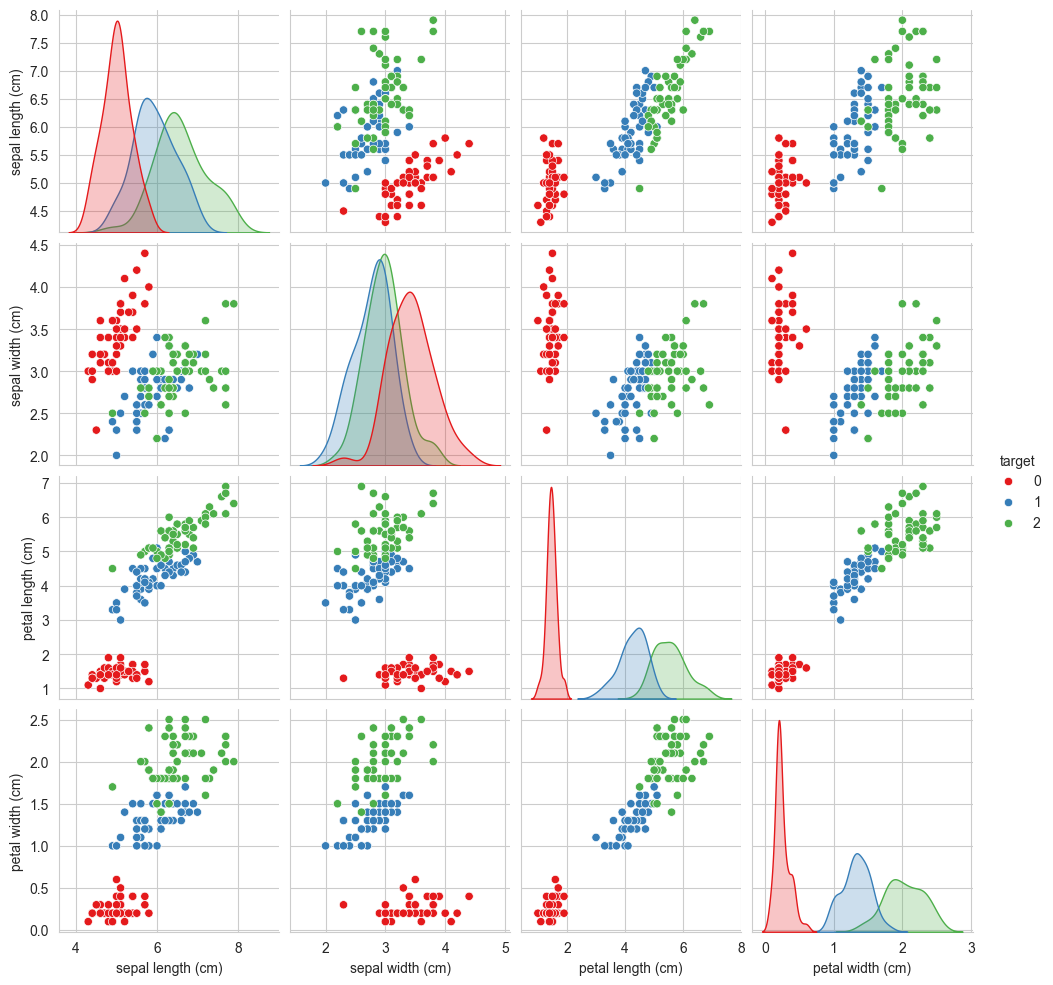

In [5]:
sns.pairplot(df, hue='target', palette='Set1')
plt.show()

In [6]:
from sklearn.cluster import KMeans

inertias = []
for k in range(2,6):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(df.iloc[:, :-1])
    inertias.append(model.inertia_)

print(inertias)

[152.3479517603579, 78.85144142614601, 57.22847321428571, 46.461172672672674]


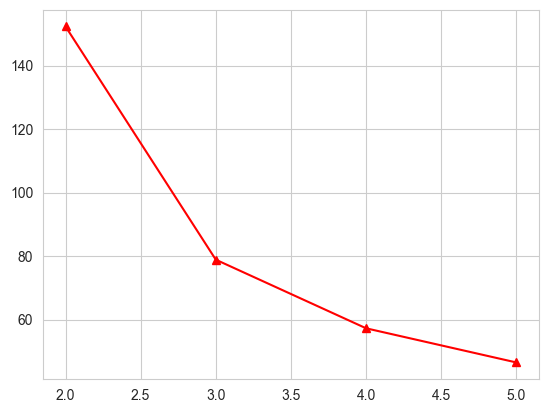

In [7]:
plt.plot(range(2,6), inertias, marker="^", color='red')
plt.show()

In [8]:
kmeans = KMeans(n_clusters = 3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df.iloc[:, :-1])
df.head(100)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1
...,...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,1,0
96,5.7,2.9,4.2,1.3,1,0
97,6.2,2.9,4.3,1.3,1,0
98,5.1,2.5,3.0,1.1,1,0


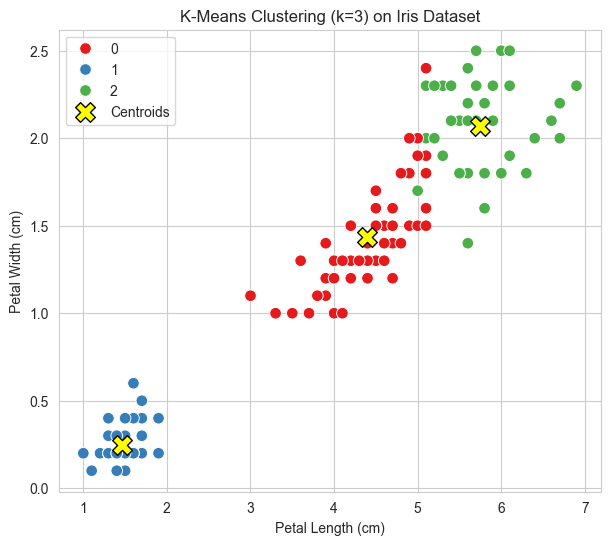

In [9]:
# Scatter plot of clusters
plt.figure(figsize=(7, 6))
sns.scatterplot(x=df["petal length (cm)"], 
                y=df["petal width (cm)"], 
                hue=df["cluster"], 
                palette="Set1", 
                s=70)
plt.scatter(kmeans.cluster_centers_[:, 2], 
            kmeans.cluster_centers_[:, 3], 
            s=200, c="yellow", marker="X", edgecolor="black", label="Centroids")
plt.title("K-Means Clustering (k=3) on Iris Dataset")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend()
plt.show()

In [22]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_true = df["target"]

y_pred= df['cluster']

cm = confusion_matrix(y_true=y_true, y_pred=y_pred)
print(cm)

[[ 0 50  0]
 [48  0  2]
 [14  0 36]]


In [34]:
from scipy.stats import mode
# Reorder cluster labels to best match true labels
import numpy as np


labels = np.zeros_like(y_pred)
for i in range(3):
    mask = (y_pred == i)
    labels[mask] = mode(y_true[mask])[0]

acc = accuracy_score(y_true, labels)
print(f"Accuracy of K-Means clustering: {acc:.2f}")

Accuracy of K-Means clustering: 0.89


* K_Means ==> outliers sensetive
* K_mediod ==> median
### ARI, Silhouette


### ARI ==> 0,1 هر چه قدر بسمت 1 نزدیک بشه یعنی خوشه بندی عالیه

In [37]:
from sklearn.metrics import adjusted_rand_score, silhouette_score

ari = adjusted_rand_score(y_true, y_pred)
ari

0.7302382722834697

### Silhoutte ==> بین -1 و 1  , بالاتر از 0.5 یعنی خوشه بندی خوب

In [41]:
silhouette_score(df.iloc[:,:-2], y_pred)

0.5528190123564101

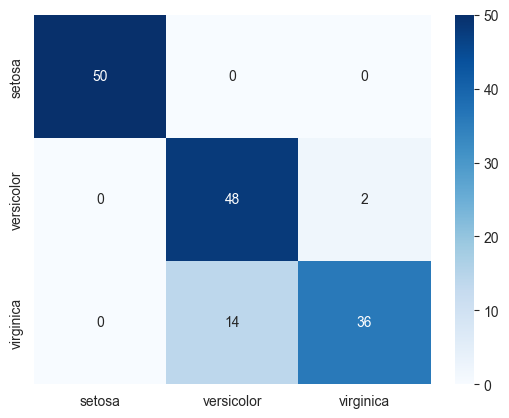

In [49]:
sns.heatmap(confusion_matrix(y_true, labels), cmap="Blues", annot=True, fmt='d', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.show()

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
X = df.iloc[:,:-2]
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [60]:
log_reg = LogisticRegression(max_iter=1000)
knn = KNeighborsClassifier(n_neighbors=6)
svm = SVC(kernel='linear')


In [63]:
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred=y_pred_log)

In [64]:
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred=y_pred_knn)

In [65]:
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred=y_pred_svm)

C:\Users\G N A\AppData\Local\Temp\ipykernel_20316\3802645876.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=result_df.index, y="Accuracy", data=result_df, palette='viridis')


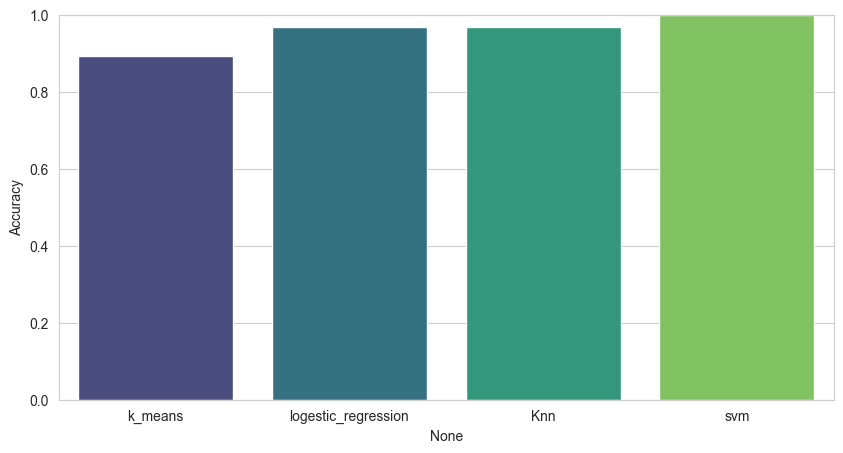

In [72]:
results = {
    'k_means':acc,
    'logestic_regression':acc_lr,
    'Knn':acc_knn,
    'svm':acc_svm
}

result_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
plt.figure(figsize=(10,5))
sns.barplot(x=result_df.index, y="Accuracy", data=result_df, palette='viridis')
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.show()